In [9]:
import numpy as np
import pandas as pd 
import matplotlib as plt 
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import warnings

In [10]:
warnings.filterwarnings("ignore")

We chose to work with the WGS data using the somatic mutations dataset as it was the one who provided the best results when trying the same approach on the different datasets for both WGS and WES data.  

# Initial approach to pick best performing model

In [11]:
#loading the dataset
df_somatic_mutations = pd.read_csv("./project_data/catalogs/WGS/WGS_PCAWG.96.csv")
df_somatic_mutations = df_somatic_mutations.set_index (df_somatic_mutations['Mutation type'] + "_" + df_somatic_mutations['Trinucleotide'])

df_somatic_mutations.head()

,Mutation type,Trinucleotide,Biliary-AdenoCA::SP117655,Biliary-AdenoCA::SP117556,Biliary-AdenoCA::SP117627,Biliary-AdenoCA::SP117775,Biliary-AdenoCA::SP117332,Biliary-AdenoCA::SP117712,Biliary-AdenoCA::SP117017,Biliary-AdenoCA::SP117031,...,Uterus-AdenoCA::SP94540,Uterus-AdenoCA::SP95222,Uterus-AdenoCA::SP89389,Uterus-AdenoCA::SP90503,Uterus-AdenoCA::SP92460,Uterus-AdenoCA::SP92931,Uterus-AdenoCA::SP91265,Uterus-AdenoCA::SP89909,Uterus-AdenoCA::SP90629,Uterus-AdenoCA::SP95550
C>A_ACA,C>A,ACA,269,114,105,217,52,192,54,196,...,117,233,94,114,257,139,404,97,250,170
C>A_ACC,C>A,ACC,148,56,71,123,36,139,54,102,...,90,167,59,64,268,75,255,78,188,137
C>A_ACG,C>A,ACG,25,13,13,29,8,31,12,15,...,12,29,14,19,51,13,52,14,49,32
C>A_ACT,C>A,ACT,154,70,73,126,31,119,41,122,...,82,213,66,68,271,68,281,80,202,116
C>A_CCA,C>A,CCA,215,63,71,129,30,190,54,133,...,119,188,67,89,307,69,339,204,194,127


In [12]:
df_somatic_mutations.shape

(96, 2782)

In [13]:
#seperate the cancer types
cancer_types_1 = np.array([ s.split(":")[0].split("-")[1] for s in df_somatic_mutations.columns[2:] ])
cancer_types_1

array(['AdenoCA', 'AdenoCA', 'AdenoCA', ..., 'AdenoCA', 'AdenoCA',
       'AdenoCA'], dtype='<U9')

In [14]:
#check the unique cancer types 
pd.unique(cancer_types_1)

array(['AdenoCA', 'TCC', 'Benign', 'Epith', 'Osteosarc', 'DCIS',
       'LobularCA', 'GBM', 'Medullo', 'Oligo', 'PiloAstro', 'SCC',
       'ChRCC', 'RCC', 'HCC', 'BNHL', 'CLL', 'AML', 'MDS', 'MPN',
       'Endocrine', 'Melanoma', 'Leiomyo', 'Liposarc'], dtype='<U9')

In [15]:
#splitting between train and test parts 
X_train, X_test, y_train, y_test = train_test_split(df_somatic_mutations.iloc[:, 2:].T, cancer_types_1, stratify=cancer_types_1)

LazyClassifier is a python library that allows to run all of the traditional machine learning models all at once without requiring to import and run each one of them seperately, which is a good approach to try to see which model performs the best before fine-tuning anf allows to save time. 

In [16]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20050
[LightGBM] [Info] Number of data points in the train set: 2085, number of used features: 96
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -0.803048
[LightGBM] [Info] Start training from score -3.260497
[LightGBM] [Info] Start training from score -5.157617
[LightGBM] [Info] Start training from score -3.379844
[LightGBM] [Info] Start training from score -4.116164
[LightGBM] [Info] Start training from score -6.949377
[LightGBM] [Info] Start training from score -3.483641
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -4.208537
[LightGBM] [Info] Start training from score -2.141266
[LightGBM] [Info] Start training from score -5.244629
[LightGBM] [Info] Start training from score -5.003467
[LightGBM

In [17]:
print(models)

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     0.83               0.55    None      0.82   
RandomForestClassifier             0.79               0.45    None      0.76   
BaggingClassifier                  0.75               0.42    None      0.73   
ExtraTreesClassifier               0.77               0.41    None      0.74   
GaussianNB                         0.27               0.38    None      0.25   
KNeighborsClassifier               0.76               0.38    None      0.73   
DecisionTreeClassifier             0.65               0.37    None      0.66   
LinearSVC                          0.77               0.37    None      0.73   
PassiveAggressiveClassifier        0.71               0.34    None      0.68   
NearestCentroid                    0.31               0.32    None      0.34   
LabelPropagation                   0.70 

From these results, it shows that LGBMClassifier performs the best across the accuracy, the balanced accuracy and the F1 score. It is closely followed by RandomForestClassifier and ExtraTreesClassifier. We chose to work with LGBMClassifier and explore ways to make it reach better results

# Exploring methods to balance imbalanced data

In [18]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

In [19]:
#exploring how many samples for each cancer type in the overall dataset 
counter = Counter(cancer_types_1)
dict(counter)

{np.str_('AdenoCA'): 1245,
 np.str_('TCC'): 23,
 np.str_('Benign'): 16,
 np.str_('Epith'): 11,
 np.str_('Osteosarc'): 38,
 np.str_('DCIS'): 3,
 np.str_('LobularCA'): 13,
 np.str_('GBM'): 41,
 np.str_('Medullo'): 146,
 np.str_('Oligo'): 18,
 np.str_('PiloAstro'): 89,
 np.str_('SCC'): 123,
 np.str_('ChRCC'): 45,
 np.str_('RCC'): 144,
 np.str_('HCC'): 326,
 np.str_('BNHL'): 107,
 np.str_('CLL'): 95,
 np.str_('AML'): 11,
 np.str_('MDS'): 4,
 np.str_('MPN'): 56,
 np.str_('Endocrine'): 85,
 np.str_('Melanoma'): 107,
 np.str_('Leiomyo'): 15,
 np.str_('Liposarc'): 19}

We can notice that while some cancer types such as AdenoCA and TCC have a large number of samples, other types like MDS and AML have very low number of samples, making our dataset highly imbalanced and leading to the model performing best on highly occuring cancer types while performing badly on rare cancer types, explaining why the balanced accuracy was low when explored earlier. 

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df_somatic_mutations.iloc[:, 2:].T, cancer_types_1, stratify=cancer_types_1)

In [21]:
#exploring how many samples for each cancer types we have in the training set 
counter_2 = Counter(y_train)
dict(counter_2)

{np.str_('Benign'): 12,
 np.str_('Endocrine'): 64,
 np.str_('CLL'): 71,
 np.str_('AdenoCA'): 934,
 np.str_('MPN'): 42,
 np.str_('PiloAstro'): 67,
 np.str_('HCC'): 245,
 np.str_('Medullo'): 110,
 np.str_('SCC'): 92,
 np.str_('Melanoma'): 80,
 np.str_('LobularCA'): 10,
 np.str_('BNHL'): 80,
 np.str_('GBM'): 31,
 np.str_('RCC'): 108,
 np.str_('AML'): 8,
 np.str_('Osteosarc'): 28,
 np.str_('Liposarc'): 14,
 np.str_('Epith'): 8,
 np.str_('ChRCC'): 34,
 np.str_('Leiomyo'): 11,
 np.str_('Oligo'): 14,
 np.str_('TCC'): 17,
 np.str_('DCIS'): 2,
 np.str_('MDS'): 3}

This showcases how the model sees some cancer types very rarely and we therefore need some balancing methods. RandomOverSampler was used which is a bootstrapping method that increases the number of samples by randomly samples with replacing from the current sample. We chose to manually provide how many instances to get for each type to avoid overfitting as much as possible. Very low classes were provided a value of 100 while classes with higher number of samples around 150 to 200.

In [22]:
oversample = RandomOverSampler(sampling_strategy={np.str_('Medullo'): 200,
 np.str_('RCC'): 200,
 np.str_('CLL'): 200,
 np.str_('Endocrine'): 200,
 np.str_('Melanoma'): 200,
 np.str_('TCC'): 100,
 np.str_('MPN'): 150,
 np.str_('BNHL'): 200,
 np.str_('ChRCC'): 150,
 np.str_('Benign'): 100,
 np.str_('PiloAstro'): 200,
 np.str_('Epith'): 100,
 np.str_('SCC'): 250,
 np.str_('GBM'): 150,
 np.str_('LobularCA'): 100,
 np.str_('Liposarc'): 100,
 np.str_('Oligo'): 100,
 np.str_('AML'): 100,
 np.str_('Osteosarc'): 100,
 np.str_('MDS'): 100,
 np.str_('Leiomyo'): 110,
 np.str_('DCIS'): 100})
X_over, y_over = oversample.fit_resample(X_train, y_train)
counter_3 = Counter(y_over)
dict(counter_3)


{np.str_('Benign'): 100,
 np.str_('Endocrine'): 200,
 np.str_('CLL'): 200,
 np.str_('AdenoCA'): 934,
 np.str_('MPN'): 150,
 np.str_('PiloAstro'): 200,
 np.str_('HCC'): 245,
 np.str_('Medullo'): 200,
 np.str_('SCC'): 250,
 np.str_('Melanoma'): 200,
 np.str_('LobularCA'): 100,
 np.str_('BNHL'): 200,
 np.str_('GBM'): 150,
 np.str_('RCC'): 200,
 np.str_('AML'): 100,
 np.str_('Osteosarc'): 100,
 np.str_('Liposarc'): 100,
 np.str_('Epith'): 100,
 np.str_('ChRCC'): 150,
 np.str_('Leiomyo'): 110,
 np.str_('Oligo'): 100,
 np.str_('TCC'): 100,
 np.str_('DCIS'): 100,
 np.str_('MDS'): 100}

In [23]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20125
[LightGBM] [Info] Number of data points in the train set: 2085, number of used features: 96
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -0.803048
[LightGBM] [Info] Start training from score -3.260497
[LightGBM] [Info] Start training from score -5.157617
[LightGBM] [Info] Start training from score -3.379844
[LightGBM] [Info] Start training from score -4.116164
[LightGBM] [Info] Start training from score -6.949377
[LightGBM] [Info] Start training from score -3.483641
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -4.208537
[LightGBM] [Info] Start training from score -2.141266
[LightGBM] [Info] Start training from score -5.244629
[LightGBM] [Info] Start training from score -5.003467
[LightGBM

In [24]:
print(models)

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     0.81               0.46    None      0.79   
ExtraTreesClassifier               0.76               0.40    None      0.73   
KNeighborsClassifier               0.75               0.39    None      0.72   
DecisionTreeClassifier             0.63               0.39    None      0.64   
GaussianNB                         0.28               0.38    None      0.27   
RandomForestClassifier             0.77               0.38    None      0.74   
BaggingClassifier                  0.74               0.37    None      0.72   
SGDClassifier                      0.69               0.34    None      0.69   
NearestCentroid                    0.29               0.34    None      0.32   
LinearSVC                          0.71               0.33    None      0.67   
Perceptron                         0.65 

We noticed that while the balanced accuracy did not increase compared to the non resampled data, the accuracy and the F1-score did decrease, which showcase that this strategy is not the most optimal as it leads to overfitting on the training data and performing poorly on the test data. The next step was to fine-tune the LGBMClassifier to find which parameters provide the best results 

# Fine-Tuning LGBMClassifier

In [25]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, accuracy_score



In [26]:
lgb_classifier = LGBMClassifier(class_weight="balanced", objective="multiclass", random_state=42, num_threads=-1)

#trying a bunch of different values for each parameters to find out which one performs best
parameters = {
    'num_leaves': [31, 63, 127],        
    'max_depth': [-1, 10, 20, 30],       
    'min_child_samples': [5, 10, 20]    
}

We chose to focus on the balanced accuracy and the parameters that optimize it as it is the one that is the most representative of imbalanced data 

In [27]:
grid_search = GridSearchCV(estimator=lgb_classifier, param_grid=parameters, scoring="balanced_accuracy", cv=3, n_jobs=-1)

In [28]:
grid_search.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002896 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20430
[LightGBM] [Info] Number of data points in the train set: 2085, number of used features: 96
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM

,estimator,LGBMClassifie...ndom_state=42)
,param_grid,"{'max_depth': [-1, 10, ...], 'min_child_samples': [5, 10, ...], 'num_leaves': [31, 63, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


We found that the LGBMClassifier performed the best with the given parameters 

In [29]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [30]:
print("Balanced Accuracy: ", balanced_accuracy_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Balanced Accuracy:  0.564805860689075
F1 score:  0.5826708724544735
              precision    recall  f1-score   support

         AML       0.00      0.00      0.00         3
     AdenoCA       0.82      0.90      0.85       311
        BNHL       0.84      0.78      0.81        27
      Benign       0.67      0.50      0.57         4
         CLL       0.79      0.96      0.87        24
       ChRCC       1.00      0.36      0.53        11
        DCIS       0.00      0.00      0.00         1
   Endocrine       0.67      0.76      0.71        21
       Epith       0.00      0.00      0.00         3
         GBM       0.88      0.70      0.78        10
         HCC       0.91      0.91      0.91        81
     Leiomyo       0.00      0.00      0.00         4
    Liposarc       0.33      0.20      0.25         5
   LobularCA       0.00      0.00      0.00         3
         MDS       1.00      1.00      1.00         1
         MPN       0.78      1.00      0.88        14
     Medullo 

Despite this fine-tuning approach, the results obtained were poor and while the model performed well on cancer types with large sample sizes it performed poorly on the ones that are rare. There should be another approach to deal with these rare cases, and we decided that this approach would be to drop the cancer types with a sample size smaller than a specific threshold.

# Approach after dropping the rare classes 

In [31]:
samples = df_somatic_mutations.iloc[:, 2:].columns
cancer_types_1 = pd.Series(data=[s.split(":")[0].split("-")[1] for s in samples], index=samples)
cancer_counts = cancer_types_1.value_counts()
cancer_counts

AdenoCA      1245
HCC           326
Medullo       146
RCC           144
SCC           123
BNHL          107
Melanoma      107
CLL            95
PiloAstro      89
Endocrine      85
MPN            56
ChRCC          45
GBM            41
Osteosarc      38
TCC            23
Liposarc       19
Oligo          18
Benign         16
Leiomyo        15
LobularCA      13
AML            11
Epith          11
MDS             4
DCIS            3
Name: count, dtype: int64

We chose to drop the classes with less than 20 samples as it would allow us to get rid of the super rare cancer types while keeping as much information as possible 

In [32]:
classes_enough_samples = cancer_counts[cancer_counts >= 20].index #picking 20 to start with 
y_filter = cancer_types_1[cancer_types_1.isin(classes_enough_samples)]
X_filter = df_somatic_mutations[y_filter.index]
X_filter = X_filter.T
X_filter

,C>A_ACA,C>A_ACC,C>A_ACG,C>A_ACT,C>A_CCA,C>A_CCC,C>A_CCG,C>A_CCT,C>A_GCA,C>A_GCC,...,T>G_CTG,T>G_CTT,T>G_GTA,T>G_GTC,T>G_GTG,T>G_GTT,T>G_TTA,T>G_TTC,T>G_TTG,T>G_TTT
Biliary-AdenoCA::SP117655,269,148,25,154,215,148,27,180,165,76,...,49,268,19,17,43,89,83,48,63,197
Biliary-AdenoCA::SP117556,114,56,13,70,63,49,7,69,81,37,...,23,53,8,5,20,15,26,10,31,64
Biliary-AdenoCA::SP117627,105,71,13,73,71,55,8,61,61,50,...,8,44,7,6,14,14,16,8,15,52
Biliary-AdenoCA::SP117775,217,123,29,126,129,82,26,143,162,84,...,43,132,21,7,28,34,38,30,53,122
Biliary-AdenoCA::SP117332,52,36,8,31,30,22,10,38,21,25,...,8,18,2,4,7,7,15,8,16,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uterus-AdenoCA::SP92931,139,75,13,68,69,52,16,55,73,32,...,23,82,8,9,14,23,19,13,25,66
Uterus-AdenoCA::SP91265,404,255,52,281,339,170,52,261,264,137,...,88,230,57,32,97,118,83,49,108,223
Uterus-AdenoCA::SP89909,97,78,14,80,204,390,92,876,77,62,...,75,76,10,7,10,24,19,17,34,106
Uterus-AdenoCA::SP90629,250,188,49,202,194,124,28,150,142,95,...,87,197,42,35,72,113,108,92,103,270


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_filter, y_filter, stratify=y_filter)

In [34]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19994
[LightGBM] [Info] Number of data points in the train set: 2002, number of used features: 96
[LightGBM] [Info] Start training from score -0.762426
[LightGBM] [Info] Start training from score -3.219875
[LightGBM] [Info] Start training from score -3.339222
[LightGBM] [Info] Start training from score -4.075541
[LightGBM] [Info] Start training from score -3.443019
[LightGBM] [Info] Start training from score -4.167915
[LightGBM] [Info] Start training from score -2.104734
[LightGBM] [Info] Start training from score -3.864232
[LightGBM] [Info] Start training from score -2.910554
[LightGBM] [Info] Start training from score -3.219875
[LightGBM] [Info] Start training from score -4.234606
[LightGBM] [Info] Start training from score -3.397209
[LightGBM] [Info] Start training from score -2.919771
[LightGBM

In [35]:
print(models)

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     0.87               0.69    None      0.86   
RandomForestClassifier             0.84               0.62    None      0.83   
PassiveAggressiveClassifier        0.76               0.60    None      0.76   
KNeighborsClassifier               0.81               0.57    None      0.79   
BaggingClassifier                  0.79               0.57    None      0.78   
ExtraTreesClassifier               0.82               0.56    None      0.79   
DecisionTreeClassifier             0.70               0.54    None      0.70   
SGDClassifier                      0.77               0.53    None      0.74   
LinearSVC                          0.78               0.53    None      0.74   
Perceptron                         0.72               0.50    None      0.70   
GaussianNB                         0.31 

We can notice that the accuracy, balanced accuracy and F1-score have greatly improved, showing that dropping the rare classes was a good approach despite the lost information as it allows the model to deal better with imbalanced data. We once again tried to fine-tune it to reach the parameters with the best possible results. 

In [36]:
lgb_classifier = LGBMClassifier(class_weight="balanced", objective="multiclass", random_state=42, num_threads=-1)

#trying a bunch of different values for each parameters to find out which one performs best
parameters = {
    'num_leaves': [31, 63, 127],        
    'max_depth': [-1, 10, 20, 30],       
    'min_child_samples': [5, 10, 20]    
}

In [37]:
grid_search = GridSearchCV(estimator=lgb_classifier, param_grid=parameters, scoring="balanced_accuracy", cv=3, n_jobs=-1)

In [38]:
grid_search.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003864 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20398
[LightGBM] [Info] Number of data points in the train set: 2002, number of used features: 96
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM

,estimator,LGBMClassifie...ndom_state=42)
,param_grid,"{'max_depth': [-1, 10, ...], 'min_child_samples': [5, 10, ...], 'num_leaves': [31, 63, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [39]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [40]:
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Balanced Accuracy: ", balanced_accuracy_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Accuracy Score:  0.8787425149700598
Balanced Accuracy:  0.7556369935973728
F1 score:  0.7864257257289875
              precision    recall  f1-score   support

     AdenoCA       0.87      0.94      0.91       311
        BNHL       0.93      0.93      0.93        27
         CLL       0.85      0.92      0.88        24
       ChRCC       0.80      0.36      0.50        11
   Endocrine       0.81      0.81      0.81        21
         GBM       0.83      0.50      0.62        10
         HCC       0.99      0.91      0.95        82
         MPN       1.00      0.86      0.92        14
     Medullo       0.89      0.68      0.77        37
    Melanoma       0.96      0.93      0.94        27
   Osteosarc       0.75      0.33      0.46         9
   PiloAstro       0.70      0.95      0.81        22
         RCC       0.97      0.94      0.96        36
         SCC       0.71      0.77      0.74        31
         TCC       0.75      0.50      0.60         6

    accuracy                 

Using this approach, we were able to reach 0.88 in accuracy, 0.76 in balanced accuracy and 0.78 in F1 score, and the model is able to deal well with imbalanced data despite the limitations. 

# Visualization 

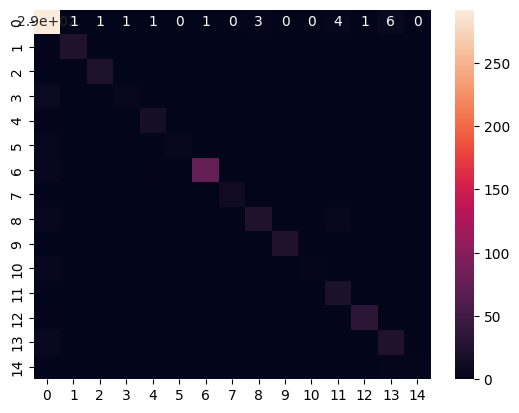

In [41]:
ax = sns.heatmap(confusion_matrix(y_test, best_model.predict(X_test)), annot = True);

The results obtained in the diagonal are pretty high. The number of samples that were misclassified was pretty minimal which showcases that our model is able to provide good results. We also notice that the model performed best on AdenoCA which is the cancer type with the most samples 

We chose to invistigate further the two cancer types with the most samples (AdenoCA and HCC) and the two cancer types with the least samples (Osteosarc and TCC). 

In [42]:
y_filter.value_counts()

AdenoCA      1245
HCC           326
Medullo       146
RCC           144
SCC           123
Melanoma      107
BNHL          107
CLL            95
PiloAstro      89
Endocrine      85
MPN            56
ChRCC          45
GBM            41
Osteosarc      38
TCC            23
Name: count, dtype: int64

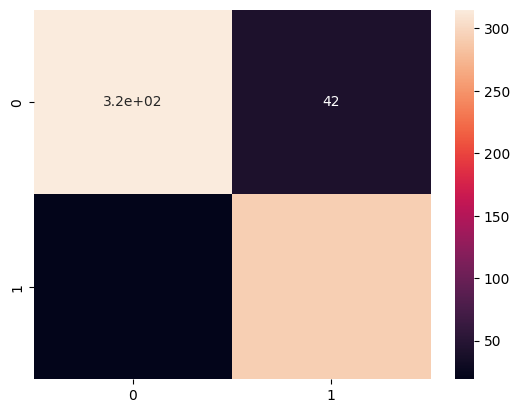

In [43]:
sns.heatmap(confusion_matrix(y_test == "AdenoCA", best_model.predict(X_test) == "AdenoCA"), annot = True);

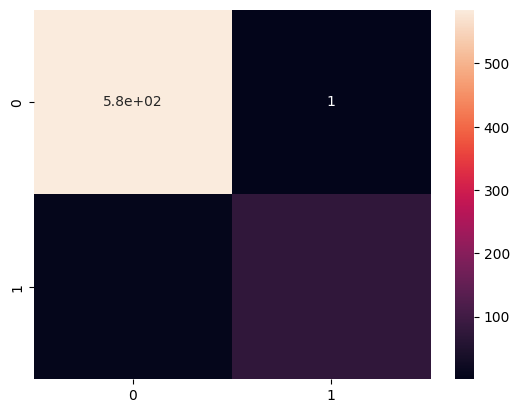

In [44]:
sns.heatmap(confusion_matrix(y_test == "HCC", best_model.predict(X_test) == "HCC"), annot = True);

We notice that the model correctly predicts the class most of the time and that the number of misclassifications is minimal for both cancer types with a low of samples and the ones that are more rare.

# Other approaches

We tried working with RandomForest and Extratreeclassifier as they were the 2nd and 3rd best performing, however they did not provide results as good as LGBMClassifier. We also tried to combine the datasets and were able to reach an accuracy of 80% without dropping any cancer types, showcasing this as a promising second approach. We also tried using NeuralNetworks which provided results of 75%. Overall, we picked LGBMClassifier as our final result to present as it was the one that provided the best results. 